# EDA — previous_application.csv

## Step 1 — Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Libraries loaded")

Libraries loaded


## Step 2 — Load Data

In [22]:
df = pd.read_csv("data/application_train.csv")
df.columns = df.columns.str.lower().str.strip()
if "target" in df.columns:
    df = df.rename(columns={"target": "default"})

prev = pd.read_csv("data/previous_application.csv")
prev.columns = prev.columns.str.lower().str.strip()

print("application_train shape   :", df.shape)
print("previous_application shape:", prev.shape)

application_train shape   : (307511, 122)
previous_application shape: (1670214, 37)


## Step 3 

In [24]:
prev.head()

,sk_id_prev,sk_id_curr,name_contract_type,amt_annuity,amt_application,amt_credit,amt_down_payment,amt_goods_price,weekday_appr_process_start,hour_appr_process_start,flag_last_appl_per_contract,nflag_last_appl_in_day,rate_down_payment,rate_interest_primary,rate_interest_privileged,name_cash_loan_purpose,name_contract_status,days_decision,name_payment_type,code_reject_reason,name_type_suite,name_client_type,name_goods_category,name_portfolio,name_product_type,channel_type,sellerplace_area,name_seller_industry,cnt_payment,name_yield_group,product_combination,days_first_drawing,days_first_due,days_last_due_1st_version,days_last_due,days_termination,nflag_insured_on_approval
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
print("=== COLUMNS ===")
print(prev.columns.tolist())
print()
print("=== DATA TYPES ===")
print(prev.dtypes.value_counts())

=== COLUMNS ===
['sk_id_prev', 'sk_id_curr', 'name_contract_type', 'amt_annuity', 'amt_application', 'amt_credit', 'amt_down_payment', 'amt_goods_price', 'weekday_appr_process_start', 'hour_appr_process_start', 'flag_last_appl_per_contract', 'nflag_last_appl_in_day', 'rate_down_payment', 'rate_interest_primary', 'rate_interest_privileged', 'name_cash_loan_purpose', 'name_contract_status', 'days_decision', 'name_payment_type', 'code_reject_reason', 'name_type_suite', 'name_client_type', 'name_goods_category', 'name_portfolio', 'name_product_type', 'channel_type', 'sellerplace_area', 'name_seller_industry', 'cnt_payment', 'name_yield_group', 'product_combination', 'days_first_drawing', 'days_first_due', 'days_last_due_1st_version', 'days_last_due', 'days_termination', 'nflag_insured_on_approval']

=== DATA TYPES ===
object     16
float64    15
int64       6
Name: count, dtype: int64


## Step 4 — Basic Statistics

In [27]:
prev.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sk_id_prev,1670214.0,1923089.14,532597.96,1000001.00,1461857.25,1923110.50,2384279.75,2845382.00
sk_id_curr,1670214.0,278357.17,102814.82,100001.00,189329.00,278714.50,367514.00,456255.00
amt_annuity,1297979.0,15955.12,14782.14,0.00,6321.78,11250.00,20658.42,418058.14
amt_application,1670214.0,175233.86,292779.76,0.00,18720.00,71046.00,180360.00,6905160.00
amt_credit,1670213.0,196114.02,318574.62,0.00,24160.50,80541.00,216418.50,6905160.00
amt_down_payment,774370.0,6697.40,20921.50,-0.90,0.00,1638.00,7740.00,3060045.00
amt_goods_price,1284699.0,227847.28,315396.56,0.00,50841.00,112320.00,234000.00,6905160.00
hour_appr_process_start,1670214.0,12.48,3.33,0.00,10.00,12.00,15.00,23.00
nflag_last_appl_in_day,1670214.0,1.00,0.06,0.00,1.00,1.00,1.00,1.00
rate_down_payment,774370.0,0.08,0.11,-0.00,0.00,0.05,0.11,1.00


## Step 5 — Records Per Applicant

In [29]:
print("Unique applicants           :", prev["sk_id_curr"].nunique())
print("Unique previous applications:", prev["sk_id_prev"].nunique())
print("Average applications/person :", round(
    len(prev) / prev["sk_id_curr"].nunique(), 2))

Unique applicants           : 338857
Unique previous applications: 1670214
Average applications/person : 4.93


count    338857.00
mean          4.93
std           4.22
min           1.00
25%           2.00
50%           4.00
75%           7.00
max          77.00
Name: sk_id_prev, dtype: float64


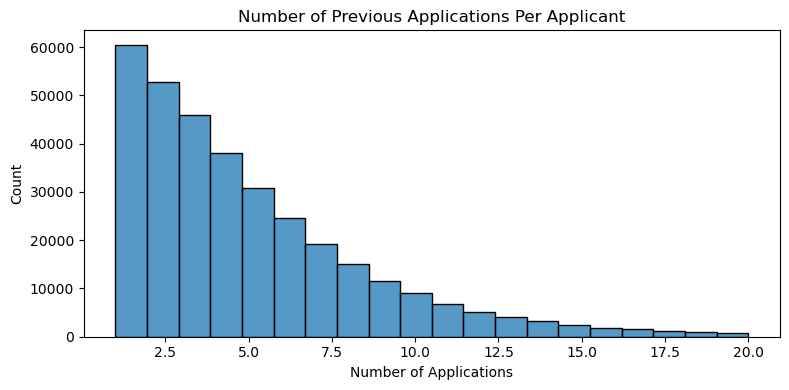

In [30]:
apps_per_person = prev.groupby("sk_id_curr")["sk_id_prev"].count()

print(apps_per_person.describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(apps_per_person[apps_per_person <= 20], bins=20)
plt.title("Number of Previous Applications Per Applicant")
plt.xlabel("Number of Applications")
plt.tight_layout()
plt.show()

## Step 6 — Missing Values

Columns with missing values: 15

rate_interest_primary        99.64
rate_interest_privileged     99.64
amt_down_payment             53.64
rate_down_payment            53.64
name_type_suite              49.12
days_first_drawing           40.30
days_first_due               40.30
days_last_due_1st_version    40.30
days_last_due                40.30
days_termination             40.30
nflag_insured_on_approval    40.30
amt_goods_price              23.08
amt_annuity                  22.29
cnt_payment                  22.29
product_combination           0.02
dtype: float64


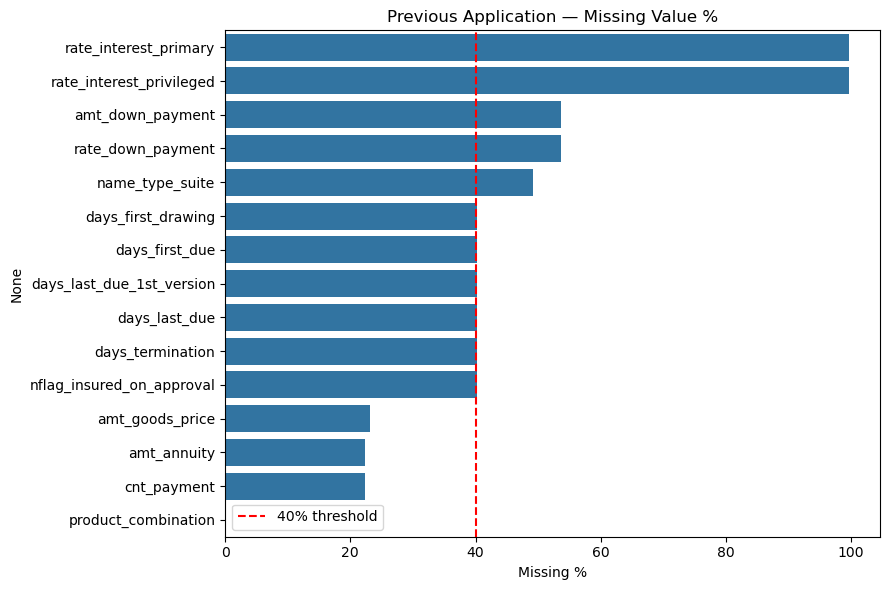

In [32]:
missing_p = (prev.isnull().sum() / len(prev) * 100).round(2)
missing_p = missing_p[missing_p > 0].sort_values(ascending=False)

print("Columns with missing values:", len(missing_p))
print()
print(missing_p)

plt.figure(figsize=(9, 6))
sns.barplot(x=missing_p.values, y=missing_p.index)
plt.axvline(40, color="red", linestyle="--", label="40% threshold")
plt.title("Previous Application — Missing Value %")
plt.xlabel("Missing %")
plt.legend()
plt.tight_layout()
plt.show()

## Step 7 — 365243 Anomaly Check

In [34]:
days_cols = [
    "days_first_drawing",
    "days_first_due",
    "days_last_due_1st_version",
    "days_last_due",
    "days_termination"
]

print("=== 365243 PLACEHOLDER CHECK ===")
print("Same anomaly as days_employed in application_train")
print()
for col in days_cols:
    count = (prev[col] == 365243).sum()
    pct   = round(count / len(prev) * 100, 2)
    print(f"{col:<35}: {count:,} rows ({pct}%)")

=== 365243 PLACEHOLDER CHECK ===
Same anomaly as days_employed in application_train

days_first_drawing                 : 934,444 rows (55.95%)
days_first_due                     : 40,645 rows (2.43%)
days_last_due_1st_version          : 93,864 rows (5.62%)
days_last_due                      : 211,221 rows (12.65%)
days_termination                   : 225,913 rows (13.53%)


## Step 8 — Distribution of Key Columns

=== CONTRACT STATUS ===
name_contract_status
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

name_contract_status
Approved        62.07
Canceled        18.94
Refused         17.40
Unused offer     1.58
Name: proportion, dtype: float64


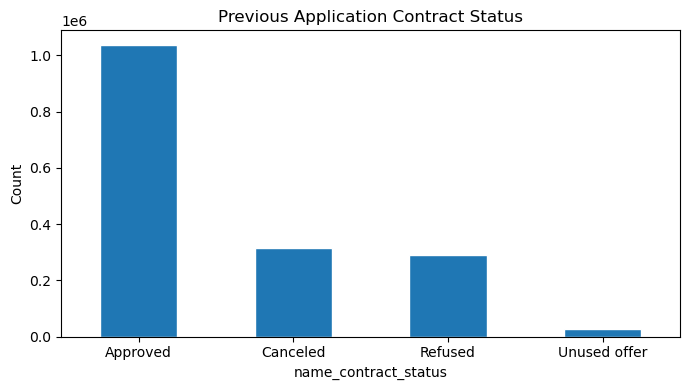

In [36]:
print("=== CONTRACT STATUS ===")
print(prev["name_contract_status"].value_counts())
print()
print((prev["name_contract_status"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(7, 4))
prev["name_contract_status"].value_counts().plot(kind="bar", edgecolor="white")
plt.title("Previous Application Contract Status")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== CONTRACT TYPE ===
name_contract_type
Cash loans         747553
Consumer loans     729151
Revolving loans    193164
XNA                   346
Name: count, dtype: int64


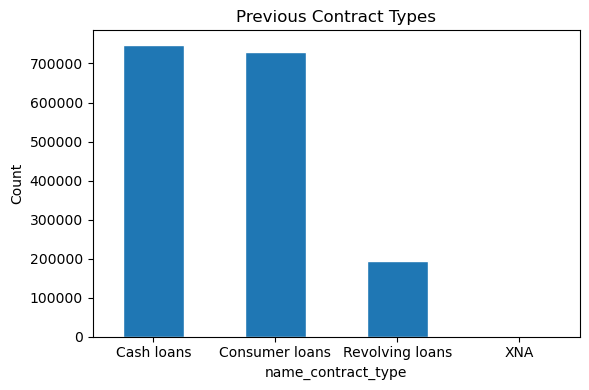

In [37]:
print("=== CONTRACT TYPE ===")
print(prev["name_contract_type"].value_counts())

plt.figure(figsize=(6, 4))
prev["name_contract_type"].value_counts().plot(kind="bar", edgecolor="white")
plt.title("Previous Contract Types")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

=== REJECTION REASONS ===
code_reject_reason
XAP       1353093
HC         175231
LIMIT       55680
SCO         37467
CLIENT      26436
SCOFR       12811
XNA          5244
VERIF        3535
SYSTEM        717
Name: count, dtype: int64


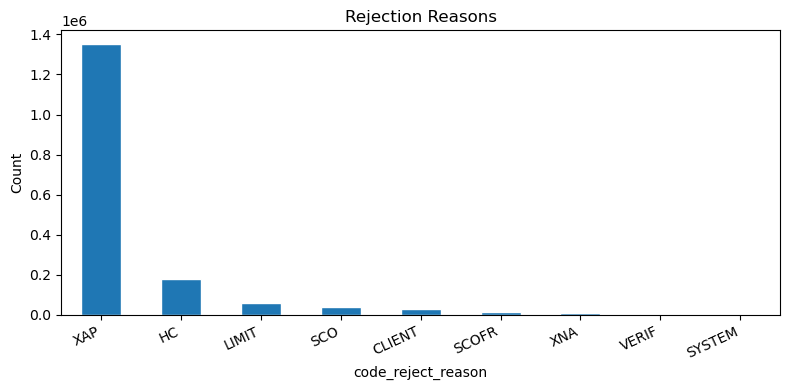

In [38]:
print("=== REJECTION REASONS ===")
print(prev["code_reject_reason"].value_counts())

plt.figure(figsize=(8, 4))
prev["code_reject_reason"].value_counts().plot(kind="bar", edgecolor="white")
plt.title("Rejection Reasons")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [39]:
print("=== CLIENT TYPE ===")
print(prev["name_client_type"].value_counts())
print()
print((prev["name_client_type"].value_counts(normalize=True) * 100).round(2))

=== CLIENT TYPE ===
name_client_type
Repeater     1231261
New           301363
Refreshed     135649
XNA             1941
Name: count, dtype: int64

name_client_type
Repeater     73.72
New          18.04
Refreshed     8.12
XNA           0.12
Name: proportion, dtype: float64


In [40]:
prev["credit_diff"] = prev["amt_credit"] - prev["amt_application"]

got_less = (prev["credit_diff"] < 0).sum()
got_more = (prev["credit_diff"] > 0).sum()
got_same = (prev["credit_diff"] == 0).sum()

print("=== CREDIT vs APPLICATION AMOUNT ===")
print("Got less than applied:", got_less,
      f"({round(got_less / len(prev) * 100, 2)}%)")
print("Got more than applied:", got_more,
      f"({round(got_more / len(prev) * 100, 2)}%)")
print("Got exactly same     :", got_same,
      f"({round(got_same / len(prev) * 100, 2)}%)")

=== CREDIT vs APPLICATION AMOUNT ===
Got less than applied: 357691 (21.42%)
Got more than applied: 657636 (39.37%)
Got exactly same     : 654886 (39.21%)


## Step 9 — Relationship with Target

In [42]:
main_ids = set(df["sk_id_curr"])
prev_ids = set(prev["sk_id_curr"])

matched  = len(main_ids & prev_ids)
no_match = len(main_ids - prev_ids)

print("Have previous records:", matched,
      f"({round(matched / len(main_ids) * 100, 2)}%)")
print("No previous records  :", no_match,
      f"({round(no_match / len(main_ids) * 100, 2)}%)")

has_prev = df[df["sk_id_curr"].isin(prev_ids)]
no_prev  = df[~df["sk_id_curr"].isin(prev_ids)]

print()
print("Default rate WITH previous records :",
      round(has_prev["default"].mean() * 100, 2), "%")
print("Default rate WITHOUT records       :",
      round(no_prev["default"].mean() * 100, 2), "%")

Have previous records: 291057 (94.65%)
No previous records  : 16454 (5.35%)

Default rate WITH previous records : 8.19 %
Default rate WITHOUT records       : 5.96 %


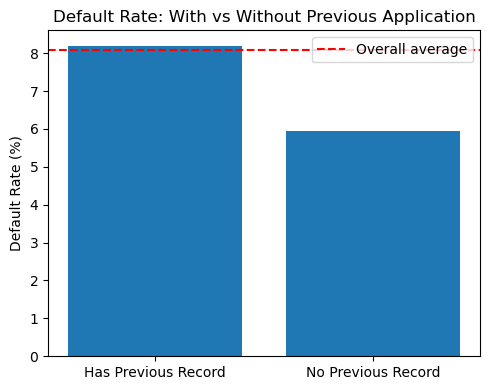

In [43]:
plt.figure(figsize=(5, 4))
plt.bar(
    ["Has Previous Record", "No Previous Record"],
    [has_prev["default"].mean() * 100,
     no_prev["default"].mean() * 100]
)
plt.title("Default Rate: With vs Without Previous Application")
plt.ylabel("Default Rate (%)")
plt.axhline(df["default"].mean() * 100, color="red",
            linestyle="--", label="Overall average")
plt.legend()
plt.tight_layout()
plt.show()

## Step 10 — Outlier Check

In [45]:
p_num   = prev.select_dtypes(include=np.number).columns.tolist()
excl_p  = ["sk_id_prev", "sk_id_curr"]
check_p = [c for c in p_num if c not in excl_p]

print(f"Checking {len(check_p)} columns\n")
print(f"{'Column':<40} {'1%':>12} {'99%':>12} {'Max':>15} {'Outlier?'}")
print("-" * 90)

outliers_p = []
for col in check_p:
    q01     = prev[col].quantile(0.01)
    q99     = prev[col].quantile(0.99)
    max_val = prev[col].max()
    is_out  = (max_val > q99 * 3) if q99 > 0 else (
               max_val > 100 if q99 == 0 else False)
    flag    = "YES" if is_out else "ok"
    if is_out:
        outliers_p.append(col)
    print(f"{col:<40} {q01:>12.2f} {q99:>12.2f} {max_val:>15.2f}  {flag}")

print()
print("Outlier columns:")
for c in outliers_p:
    print(" -", c)

Checking 20 columns

Column                                             1%          99%             Max Outlier?
------------------------------------------------------------------------------------------
amt_annuity                                   2137.18     69685.79       418058.15  YES
amt_application                                  0.00   1350000.00      6905160.00  YES
amt_credit                                       0.00   1515377.70      6905160.00  YES
amt_down_payment                                 0.00     65930.89      3060045.00  YES
amt_goods_price                              15300.00   1395000.00      6905160.00  YES
hour_appr_process_start                          5.00        20.00           23.00  ok
nflag_last_appl_in_day                           1.00         1.00            1.00  ok
rate_down_payment                                0.00         0.52            1.00  ok
rate_interest_primary                            0.06         0.70            1.00  ok
rate_int

## Observations

- 1,670,214 records, 37 columns. Average 4.93 applications per person.
- 94.65% of applicants have previous application records.
- Applicants WITHOUT records default LESS: 5.96% vs 8.19%. New customers are more careful.
- rate_interest columns have 99.64% missing — drop these.
- amt_down_payment has 53.64% missing — drop this.
- 365243 placeholder found in 5 days columns — replace with NaN.
- 62.07% of previous applications were approved. 17.40% were refused.
- 39.37% of applicants received more credit than they applied for.